In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("loan_prediction.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df["Dependents"].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [ ]:
df["Dependents"]=df["Dependents"].replace('3+',3)

In [ ]:
df["Dependents"]=df["Dependents"].astype("float")

In [ ]:
df_num=df.select_dtypes(exclude="object")
df_num.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,0.0,5849,0.0,NaN,360.0,1.0
1,1.0,4583,1508.0,128.0,360.0,1.0
2,0.0,3000,0.0,66.0,360.0,1.0
3,0.0,2583,2358.0,120.0,360.0,1.0
4,0.0,6000,0.0,141.0,360.0,1.0


**Skewness=(Mean-Mode)/Std**

In [ ]:
sk=[]
def skewness(num):
  for i in num:
    a=(num[i].mean()-num[i].mode()[0])/(num[i].std())
    sk.append(a)
  return sk

In [ ]:
b=skewness(df_num)
b

[np.float64(0.7515030872196665),
 np.float64(0.47527246311577237),
 np.float64(0.5540356092387764),
 np.float64(0.30859899043957384),
 np.float64(-0.2764110367269907),
 np.float64(-0.4324768289054649)]

In [ ]:
for i in df_num:
  for j in range(len(b)):
    if -.5<=b[j]<=.5:
      df_num[i].fillna(df_num[i].mean(),inplace=True)
    else:
      df_num[i].fillna(df_num[i].median(),inplace=True)

/tmp/ipython-input-3420996597.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_num[i].fillna(df_num[i].median(),inplace=True)
/tmp/ipython-input-3420996597.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [ ]:
df_ob=df.select_dtypes(include="object")
df_ob

,Loan_ID,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
0,LP001002,Male,No,Graduate,No,Urban,Y
1,LP001003,Male,Yes,Graduate,No,Rural,N
2,LP001005,Male,Yes,Graduate,Yes,Urban,Y
3,LP001006,Male,Yes,Not Graduate,No,Urban,Y
4,LP001008,Male,No,Graduate,No,Urban,Y
...,...,...,...,...,...,...,...
609,LP002978,Female,No,Graduate,No,Rural,Y
610,LP002979,Male,Yes,Graduate,No,Rural,Y
611,LP002983,Male,Yes,Graduate,No,Urban,Y
612,LP002984,Male,Yes,Graduate,No,Urban,Y


In [ ]:
df_ob.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Education,0
Self_Employed,32
Property_Area,0
Loan_Status,0


In [ ]:
df_ob["Gender"].fillna("unknown",inplace=True)
df_ob["Self_Employed"].fillna(df_ob["Self_Employed"].mode()[0],inplace=True)
df_ob["Married"].fillna(df_ob["Married"].mode()[0],inplace=True)

/tmp/ipython-input-1009007957.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ob["Gender"].fillna("unknown",inplace=True)
/tmp/ipython-input-1009007957.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
df_ob=df_ob.drop(["Loan_ID"],axis=1)

In [ ]:
df1=pd.concat([df_num,df_ob],axis=1)

In [ ]:
df1

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
0,0.0,5849,0.0,128.0,360.0,1.0,Male,No,Graduate,No,Urban,Y
1,1.0,4583,1508.0,128.0,360.0,1.0,Male,Yes,Graduate,No,Rural,N
2,0.0,3000,0.0,66.0,360.0,1.0,Male,Yes,Graduate,Yes,Urban,Y
3,0.0,2583,2358.0,120.0,360.0,1.0,Male,Yes,Not Graduate,No,Urban,Y
4,0.0,6000,0.0,141.0,360.0,1.0,Male,No,Graduate,No,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0.0,2900,0.0,71.0,360.0,1.0,Female,No,Graduate,No,Rural,Y
610,3.0,4106,0.0,40.0,180.0,1.0,Male,Yes,Graduate,No,Rural,Y
611,1.0,8072,240.0,253.0,360.0,1.0,Male,Yes,Graduate,No,Urban,Y
612,2.0,7583,0.0,187.0,360.0,1.0,Male,Yes,Graduate,No,Urban,Y


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in df_ob:
  df1[i]=le.fit_transform(df1[i])

In [ ]:
df1.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
0,0.0,5849,0.0,128.0,360.0,1.0,1,0,0,0,2,1
1,1.0,4583,1508.0,128.0,360.0,1.0,1,1,0,0,0,0
2,0.0,3000,0.0,66.0,360.0,1.0,1,1,0,1,2,1
3,0.0,2583,2358.0,120.0,360.0,1.0,1,1,1,0,2,1
4,0.0,6000,0.0,141.0,360.0,1.0,1,0,0,0,2,1


In [ ]:
from scipy.stats import zscore
z=np.abs(zscore(df1))
df2=df1[(z<3).all(axis=1)]
print(df1.shape)
print(df2.shape)
df1=df2.copy()

(614, 12)
(577, 12)


In [ ]:
x=df1.drop("Loan_Status",axis=1)

In [ ]:
y=df1["Loan_Status"]

In [ ]:
scaler = StandardScaler()

In [ ]:
from sklearn.preprocessing import StandardScaler
x_sc=scaler.fit_transform(x)
x_sc

array([[-0.72331271,  0.39926641, -0.86103617, ..., -0.54196123,
        -0.38058018,  1.22747207],
       [ 0.2823534 , -0.02802029,  0.05284031, ..., -0.54196123,
        -0.38058018, -1.30652215],
       [-0.72331271, -0.56229742, -0.86103617, ..., -0.54196123,
         2.62756724,  1.22747207],
       ...,
       [ 0.2823534 ,  1.14954946, -0.71559164, ..., -0.54196123,
        -0.38058018,  1.22747207],
       [ 1.28801951,  0.98450744, -0.86103617, ..., -0.54196123,
        -0.38058018,  1.22747207],
       [-0.72331271, -0.02802029, -0.86103617, ..., -0.54196123,
         2.62756724, -0.03952504]])

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x_sc,y,test_size=0.25,random_state=0)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
knn.score(x_train,y_train)

0.8402777777777778

In [ ]:
y_pred = knn.predict(x_test)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.46      0.59        48
           1       0.78      0.95      0.86        97

    accuracy                           0.79       145
   macro avg       0.80      0.70      0.72       145
weighted avg       0.79      0.79      0.77       145



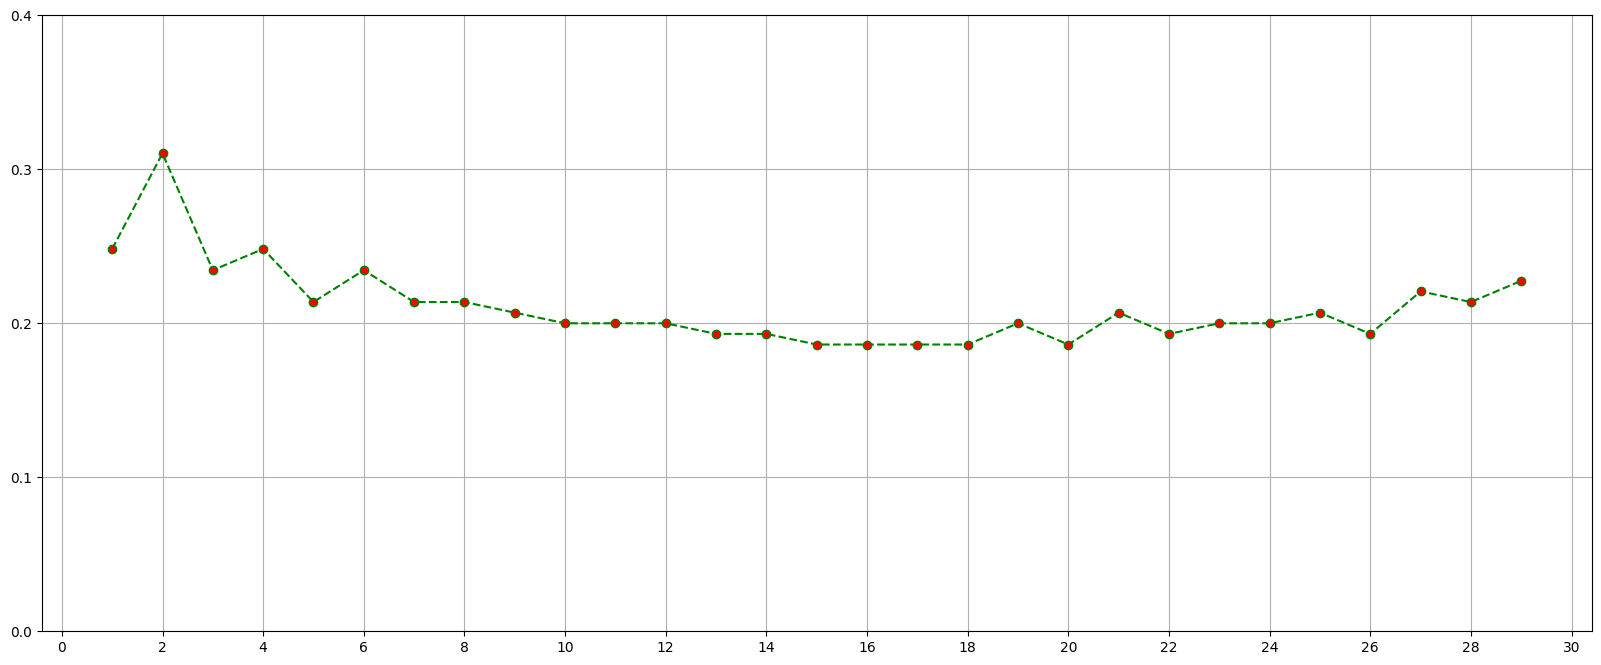

In [ ]:
error_rate=[]
for i in range(1,30):
  knc=KNeighborsClassifier(n_neighbors=i)
  knc.fit(x_train,y_train)
  y_pred_i=knc.predict(x_test)
  error_rate.append(np.mean(y_pred_i !=y_test))
plt.figure(figsize=(20,8))
plt.plot(range(1,30),error_rate,linestyle="dashed",color="green",marker="o",markerfacecolor="red")
plt.xticks(np.arange(0,32,2))
plt.yticks(np.arange(0,0.5,0.1))
plt.grid()
plt.show()

In [ ]:
min_k=error_rate[0]
for i in range(len(error_rate)):
  if error_rate[i]<min_k:
    min_k=error_rate[i]
    print(i,min_k)

2 0.23448275862068965
4 0.21379310344827587
8 0.20689655172413793
9 0.2
12 0.19310344827586207
14 0.18620689655172415


In [ ]:
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(x_train,y_train)
knn.score(x_train,y_train)

0.8078703703703703